Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.7191 - mae: 0.6038 - val_loss: 0.3272 - val_mae: 0.3909
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3333 - mae: 0.4360 - val_loss: 0.1852 - val_mae: 0.3227
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2418 - mae: 0.3806 - val_loss: 0.1527 - val_mae: 0.2961
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2058 - mae: 0.3564 - val_loss: 0.1267 - val_mae: 0.2577
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1884 - mae: 0.3397 - val_loss: 0.1246 - val_mae: 0.2600
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1841 - mae: 0.3351 - val_loss: 0.1189 - val_mae: 0.2504
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1773 - mae: 0.3294 - val_loss: 0.1107 - val_mae: 0.2421
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1732 - mae: 0.3248 - val_loss: 0.1116 - val_mae: 0.2461
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1706 - mae: 0.

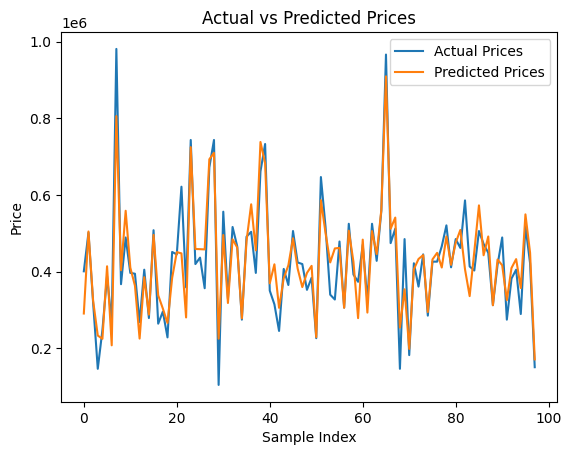

In [ ]:
# 1. Import libraries
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 2. Load dataset (upload housing.csv in Colab)
data = pd.read_csv("housing.csv")

# 3. Features & target
X = data.drop("MEDV", axis=1)
y = data["MEDV"]

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Scale features
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

# 6. 🔥 Scale target (IMPORTANT)
scaler_y = StandardScaler()
y_train = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_test = scaler_y.transform(y_test.values.reshape(-1,1))

# 7. Build DNN model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
])

# 8. Compile
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 9. Train
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

# 10. Predict
y_pred = model.predict(X_test)

# 11. 🔥 Convert back to original scale
y_pred = scaler_y.inverse_transform(y_pred)
y_test_actual = scaler_y.inverse_transform(y_test)

# 12. Show results (ONLY first 5)
print("\nSample Predictions:\n")
for i in range(5):
    print(f"Actual: {y_test_actual[i][0]:.2f}, Predicted: {y_pred[i][0]:.2f}")

plt.plot(y_test_actual, label="Actual Prices")
plt.plot(y_pred, label="Predicted Prices")
plt.xlabel("Sample Index")
plt.ylabel("Price")
plt.title("Actual vs Predicted Prices")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test_actual, y_pred)
print("MAE:", mae)

MAE: 46134.42809311225


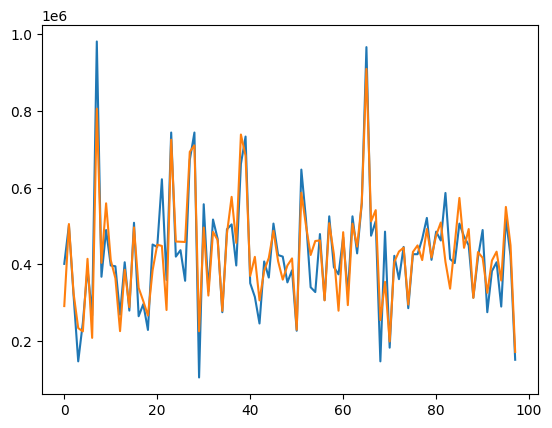

In [ ]:
plt.plot(y_test_actual, label="Actual Prices")
plt.plot(y_pred, label="Predicted Prices")